In [1]:
from pathlib import Path
import sys

def _project_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "src" / "forecasting").is_dir():
            return p
    return here


_root = _project_root()
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))
    
TARGET_COL = "sell_bid"  # change to "sell_bid" for sell-side experiments
HORIZON = 96 * 7
PARAMS_PATH = Path("data/processed/params/ts_params.json")

from forecasting.data.loaders import load_market_data
from forecasting.features.market import add_daily_clf, add_nci, add_rolling_3d_clf
from forecasting.utils.io import save_json, load_json

from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive
from statsforecast.models import AutoARIMA, ARIMA, AutoTBATS
from statsforecast.arima import arima_string

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import * # mae imported
from statsmodels.tsa.seasonal import seasonal_decompose


In [3]:
indexed_data = load_market_data("../../../data/raw/iex-dam-0201-0421.csv")
data = indexed_data.reset_index()
data.sample()

,period_start,period,purchase_bid,sell_bid,mcv,mcp,final_scheduled_volume
1295,2026-02-14 11:45:00,11:45 - 12:00,14343.5,37043.2,9992.1,2445.52,9992.1


## Seasonal Decomposition to check for stationarity

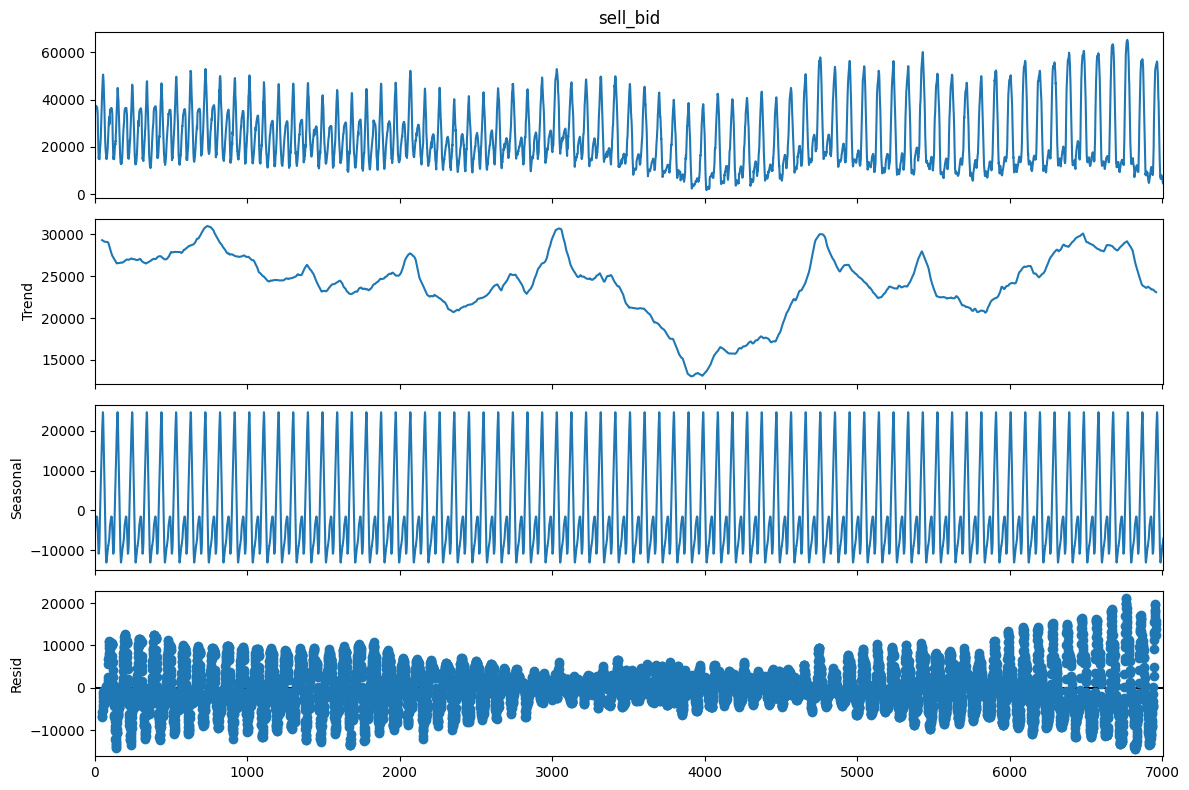

In [4]:
result = seasonal_decompose(data[TARGET_COL], model='additive', period=96)
data[f"{TARGET_COL}_resid"] = result.resid

plt.rcParams['figure.figsize'] = (12, 8)
result.plot()
plt.show()

In [5]:
# import the ADF test
from statsmodels.tsa.stattools import adfuller

# create a function that returns the necessary metrics to test stationarity
def test_stationarity(timeseries):
    dftest_initial = adfuller(timeseries)
    dfoutput_initial = pd.Series(dftest_initial[0:4], 
          index=['Statistical Test', 
                 'p-value', 
                 '#Lags used', 
                 'Number of observations'
                 ])
    for key, value in dftest_initial[4].items():
        dfoutput_initial['Critical value ' + key] = value
    print(dfoutput_initial)

test_stationarity(data[TARGET_COL])

Statistical Test         -1.410568e+01
p-value                   2.572061e-26
#Lags used                3.500000e+01
Number of observations    6.972000e+03
Critical value 1%        -3.431288e+00
Critical value 5%        -2.861955e+00
Critical value 10%       -2.566991e+00
dtype: float64


p-value suggests that the time series is stationary, but we should always check ACF and PACF plots to confirm.

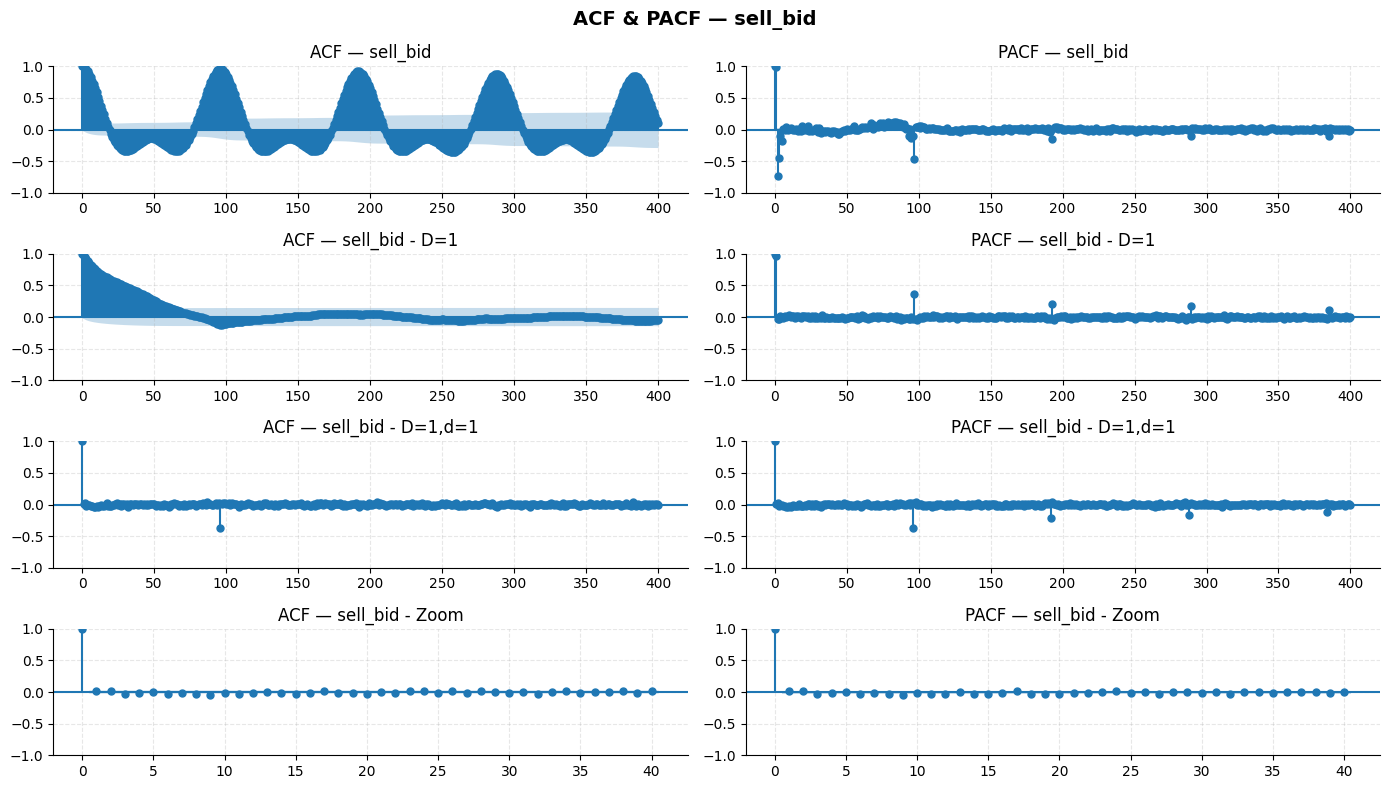

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(14, 8))
fig.suptitle(f"ACF & PACF — {TARGET_COL}", fontsize=14, fontweight="bold")

plot_acf(data[TARGET_COL].dropna(),  lags=400, ax=axes[0, 0], title=f"ACF — {TARGET_COL}")
plot_pacf(data[TARGET_COL].dropna(), lags=400, ax=axes[0, 1], title=f"PACF — {TARGET_COL}")
plot_acf(data[TARGET_COL].diff(96).dropna(),  lags=400, ax=axes[1, 0], title=f"ACF — {TARGET_COL} - D=1")
plot_pacf(data[TARGET_COL].diff(96).dropna(), lags=400, ax=axes[1, 1], title=f"PACF — {TARGET_COL} - D=1")
plot_acf(data[TARGET_COL].diff(96).diff().dropna(),  lags=400, ax=axes[2, 0], title=f"ACF — {TARGET_COL} - D=1,d=1")
plot_pacf(data[TARGET_COL].diff(96).diff().dropna(), lags=400, ax=axes[2, 1], title=f"PACF — {TARGET_COL} - D=1,d=1")
plot_acf(data[TARGET_COL].diff(96).diff().dropna(),  lags=40, ax=axes[3, 0], title=f"ACF — {TARGET_COL} - Zoom")
plot_pacf(data[TARGET_COL].diff(96).diff().dropna(), lags=40, ax=axes[3, 1], title=f"PACF — {TARGET_COL} - Zoom")

for ax in axes.flat:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

From the plots in data exploration notebook, it's evident that we should focus on modeling SARIMA time series.
- Now, SARIMA requires 7 parameters (p,d,q)(P,D,Q)m
- Here m is clearly 96 (1 day) since cyclicity is evident in a day.
- We will first start with D and d to reach stationarity. 
- After differencing with D=1, I am seeing hints of stationarity achieved. 
- Will then difference again with d=1, I am seeing ACF decaying exponentially now.
- Then I am seeing spikes at lag 96 in ACF and multiples of 96 in PACF. This gives me my Q=1 and P=1,2,3...
- Then, to get small p and q, we will zoom and see there are no significant spikes, so we will keep them 0 or 1 for now.

Although to have a baseline to compare against, I will first implement baseline models as well.

Now, in order to use a faster library of StatsForecast, I need to transform the columns as below

In [7]:
data = data.rename(columns={
    'period_start': 'ds',
    TARGET_COL: 'y',
})
filtered_data = data[["ds", "y"]].copy()
filtered_data['unique_id'] = 'series_1'
filtered_data

,ds,y,unique_id
0,2026-02-01 00:00:00,30678.9,series_1
1,2026-02-01 00:15:00,32484.0,series_1
2,2026-02-01 00:30:00,34476.2,series_1
3,2026-02-01 00:45:00,36013.3,series_1
4,2026-02-01 01:00:00,36515.8,series_1
...,...,...,...
7003,2026-04-14 22:45:00,5026.8,series_1
7004,2026-04-14 23:00:00,4582.7,series_1
7005,2026-04-14 23:15:00,4588.1,series_1
7006,2026-04-14 23:30:00,4551.7,series_1


### Evaluating last 7 days through baseline models

In [8]:
horizon = 96*7

test = filtered_data.tail(horizon)
train = filtered_data.drop(test.index).reset_index(drop=True)

models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=96*7),
    SeasonalNaive(season_length=96*7)
]

sf = StatsForecast(models=models, freq="15min")
sf.fit(df=train)

preds = sf.predict(h=horizon)
test_predictions_v1 = pd.merge(test, preds, 'left', ['ds', 'unique_id'])

metrics = evaluate(
    test_predictions_v1,
    metrics=[mae],
)
metrics.head()

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,series_1,mae,16617.033929,16187.383216,16205.159463,5591.780357


In [9]:
metrics = metrics.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
metrics

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,16617.033929,16187.383216,16205.159463,5591.780357


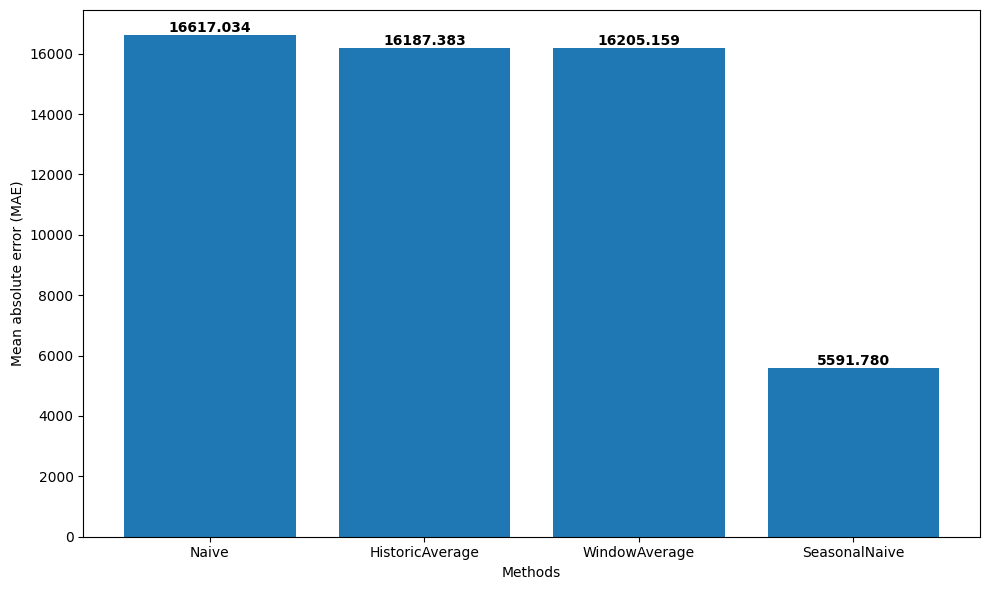

In [10]:
methods = metrics.columns[1:].tolist()  
values = metrics.iloc[0, 1:].tolist() 

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

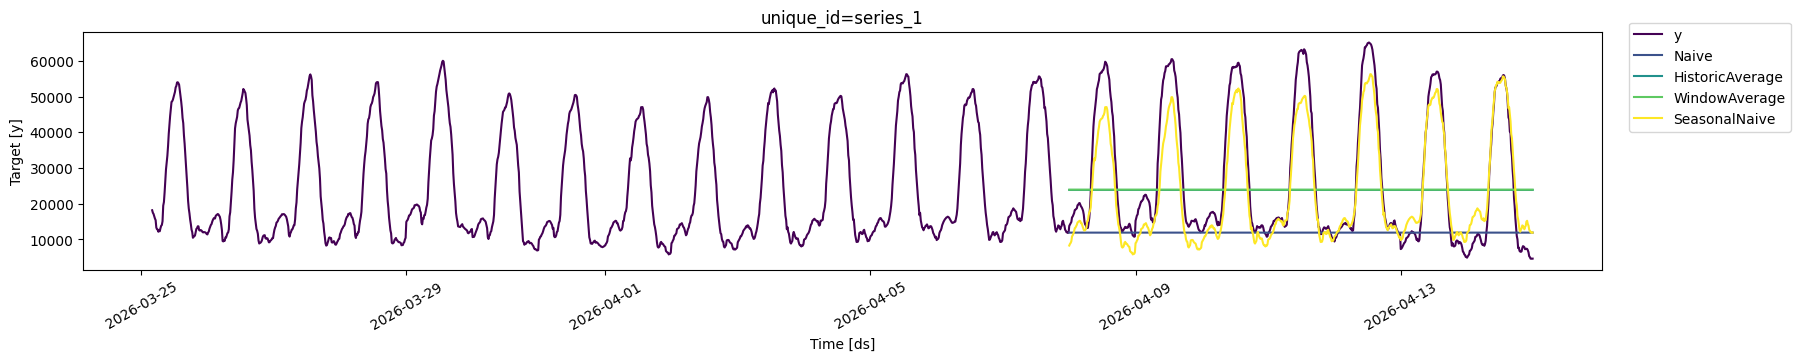

In [11]:
plot_series(
    df=filtered_data, 
    forecasts_df=preds,  
    max_insample_length=2000, 
    palette="viridis")

### SARIMA - last 7 days

In [12]:
horizon = 96*7

models = [
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (0,1,0,1,1,1,96)"),
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(0, 1, 1), alias="SARIMA (0,1,0,0,1,1,96)"),
    ARIMA(order=(1,1,1), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (1,1,1,1,1,1,96)"),
]

sf_arima = StatsForecast(models=models, freq="15min")
sf_arima.fit(df=train)
preds = sf_arima.predict(h=horizon)

test_predictions_v2 = pd.merge(test_predictions_v1, preds, 'inner', ['ds', 'unique_id'])

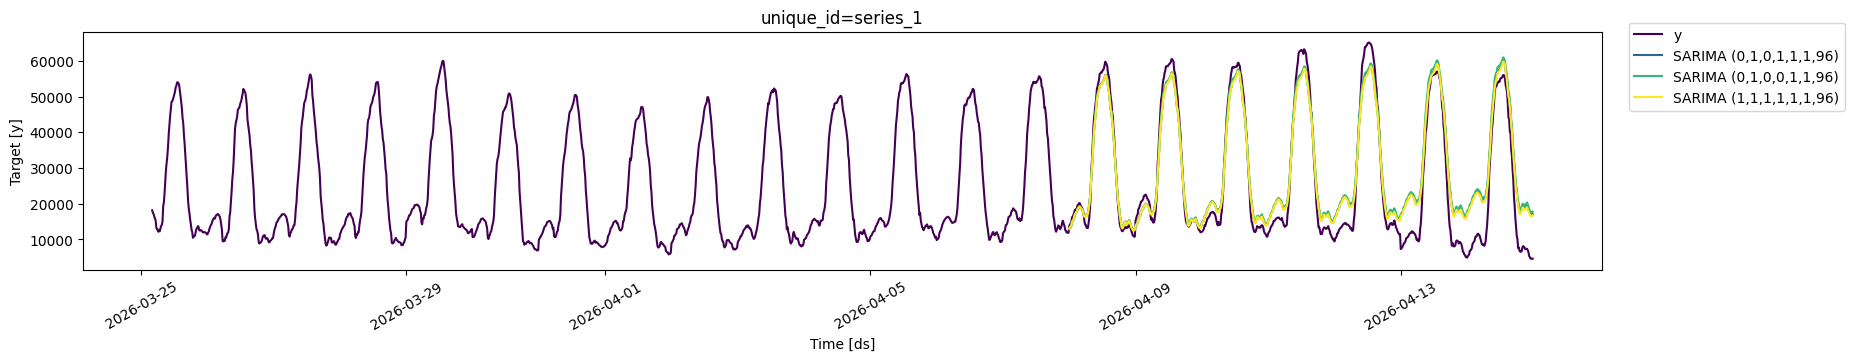

In [13]:
plot_series(
    df=filtered_data, 
    forecasts_df=preds,  
    max_insample_length=2000, 
    palette="viridis")

In [14]:
metrics = evaluate(
    test_predictions_v2,
    metrics=[mae],
)
metrics

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive,"SARIMA (0,1,0,1,1,1,96)","SARIMA (0,1,0,0,1,1,96)","SARIMA (1,1,1,1,1,1,96)"
0,series_1,mae,16617.033929,16187.383216,16205.159463,5591.780357,4626.499471,4848.497937,4514.046135


### SARIMA with Exogeneous variables - last 7 days

In [15]:
_market_exog = add_rolling_3d_clf(add_daily_clf(add_nci(indexed_data)))
_rolling_clf = _market_exog[["period_start", "rolling_3d_clf"]].rename(
    columns={"period_start": "ds"}
)

data_with_exog = filtered_data.copy()
# data_with_exog = data_with_exog.merge(_rolling_clf, on="ds", how="left")
# data_with_exog["period_enum"] = data_with_exog["ds"].dt.hour * 4 + data_with_exog["ds"].dt.minute // 15 + 1
data_with_exog["weekday_enum"] = data_with_exog["ds"].dt.weekday + 1


test = data_with_exog.groupby("unique_id").tail(horizon)
train = data_with_exog.drop(test.index).reset_index(drop=True)

futr_exog_df = test.drop(["y"], axis=1)
futr_exog_df.head()

2026-04-24 12:00:58,309 | INFO | forecasting.features.market | Loading weather master from /Users/dhruvil/Documents/EarthSync/data/weather/weather_master.csv


,ds,unique_id,weekday_enum
6336,2026-04-08 00:00:00,series_1,3
6337,2026-04-08 00:15:00,series_1,3
6338,2026-04-08 00:30:00,series_1,3
6339,2026-04-08 00:45:00,series_1,3
6340,2026-04-08 01:00:00,series_1,3


<Axes: >

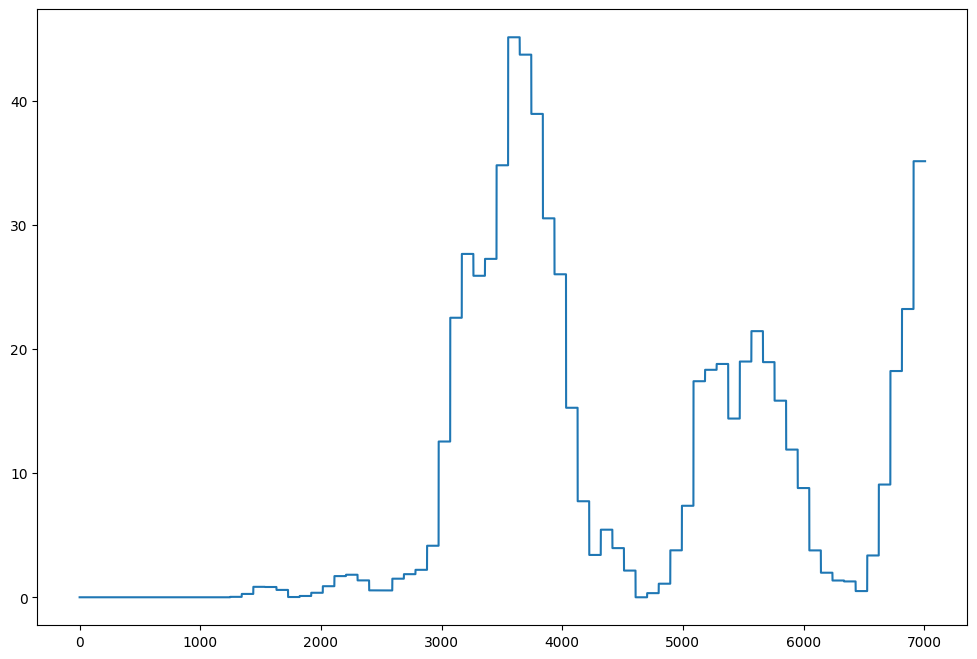

In [16]:
_market_exog.rolling_3d_clf.plot()

In [17]:
models = [
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(0, 1, 1), alias="SARIMA (0,1,0,0,1,1,96) exog")
]

sf = StatsForecast(models=models, freq="15min")
sf.fit(df=train)
exog_preds = sf.predict(h=horizon, X_df=futr_exog_df)

test_predictions_v3 = pd.merge(test_predictions_v2, exog_preds,  'inner', ['ds', 'unique_id'])

In [18]:
# arima_eval = arima_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
metrics = evaluate(
    test_predictions_v3,
    metrics=[mae],
)
metrics

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive,"SARIMA (0,1,0,1,1,1,96)","SARIMA (0,1,0,0,1,1,96)","SARIMA (1,1,1,1,1,1,96)","SARIMA (0,1,0,0,1,1,96) exog"
0,series_1,mae,16617.033929,16187.383216,16205.159463,5591.780357,4626.499471,4848.497937,4514.046135,5468.519746


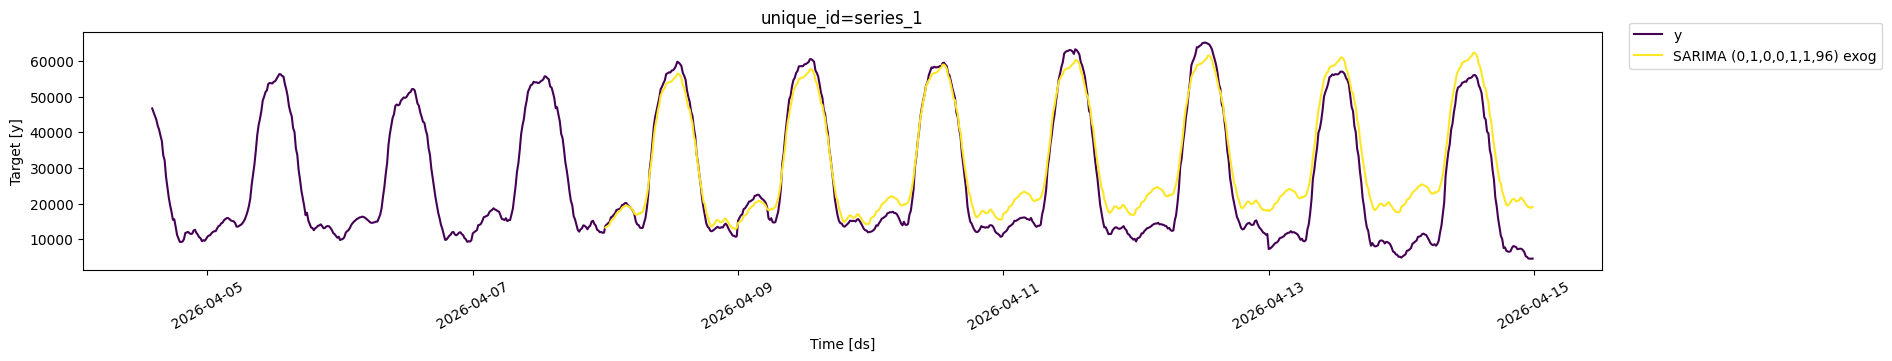

In [19]:
plot_series(
    df=filtered_data, 
    forecasts_df=exog_preds,  
    max_insample_length=1000, 
    palette="viridis")

### Metrics - last 7 days

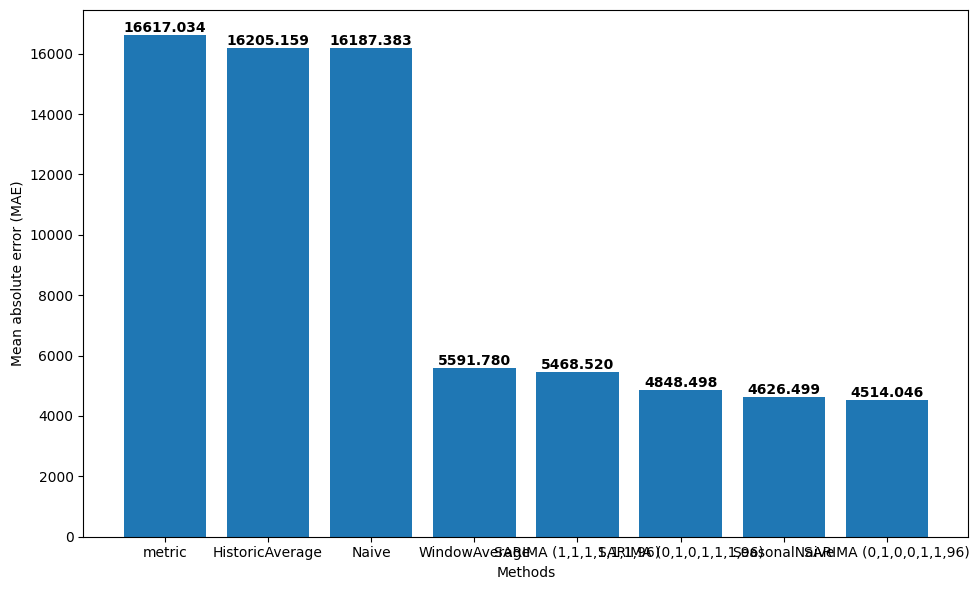

In [20]:
methods = metrics.columns[1:].tolist()  
values = metrics.iloc[0, 2:].tolist() 

sorted_data = sorted(zip(methods, values), key=lambda x: x[1], reverse=True)
methods_sorted, values_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 6))
bars = plt.bar(methods_sorted, values_sorted)

for bar, value in zip(bars, values_sorted):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

### Cross Validation for naive and ARIMA

In [21]:
models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=96*7),
    SeasonalNaive(season_length=96*7),
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (0,1,0,1,1,1,96)"),
    ARIMA(order=(1,1,1), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (1,1,1,1,1,1,96)")
]

sf = StatsForecast(models=models, freq="15min")
cv_df = sf.cross_validation(
    h=horizon,
    df=filtered_data,
    n_windows=7,
    step_size=96,
    refit=True
)

cv_df.head()

,unique_id,ds,cutoff,y,Naive,HistoricAverage,WindowAverage,SeasonalNaive,"SARIMA (0,1,0,1,1,1,96)","SARIMA (1,1,1,1,1,1,96)"
0,series_1,2026-04-02 00:00:00,2026-04-01 23:45:00,8941.8,6315.6,23789.803559,23455.978423,11374.7,7207.789932,7235.089848
1,series_1,2026-04-02 00:15:00,2026-04-01 23:45:00,9161.4,6315.6,23789.803559,23455.978423,11934.5,7593.615153,7622.755710
2,series_1,2026-04-02 00:30:00,2026-04-01 23:45:00,9656.3,6315.6,23789.803559,23455.978423,12199.7,7921.330912,7954.104198
3,series_1,2026-04-02 00:45:00,2026-04-01 23:45:00,10005.0,6315.6,23789.803559,23455.978423,13000.6,8326.508273,8360.156878
4,series_1,2026-04-02 01:00:00,2026-04-01 23:45:00,11005.0,6315.6,23789.803559,23455.978423,13541.7,9241.151318,9267.070351


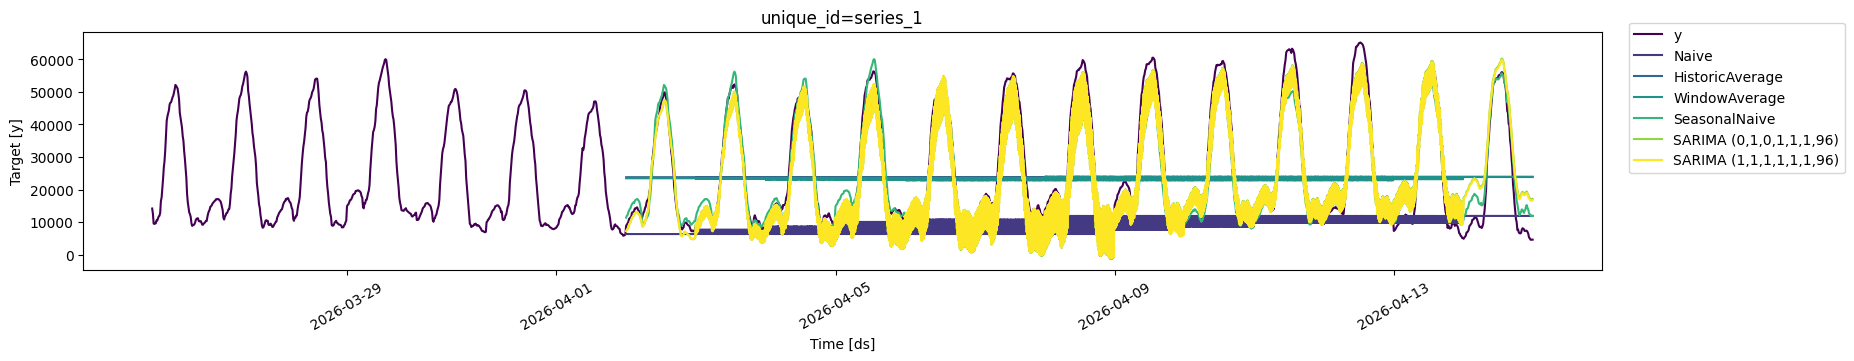

In [22]:
plot_series(
    df=filtered_data, 
    forecasts_df=cv_df.drop(["y", "cutoff"], axis=1), 
    max_insample_length=1900, 
    palette="viridis")

In [23]:
cv_eval = evaluate(
    cv_df.drop(["cutoff"], axis=1),
    metrics=[mae],
)
cv_eval = cv_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
cv_eval

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive,"SARIMA (0,1,0,1,1,1,96)","SARIMA (1,1,1,1,1,1,96)"
0,mae,18013.114286,14852.468831,14745.737465,4984.93159,4822.828069,4832.988231


### Cross Validation for SARIMA with exogenous variable

In [24]:
models = [
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (0,1,0,1,1,1,96) exog"),
    ARIMA(order=(1,1,1), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (1,1,1,1,1,1,96) exog")
]

sf = StatsForecast(models=models, freq="15min")
cv_df_exog = sf.cross_validation(
    h=horizon,
    df=data_with_exog,
    n_windows=7,
    step_size=96,
    refit=True
)
cv_df_exog.head()

,unique_id,ds,cutoff,y,"SARIMA (0,1,0,1,1,1,96) exog","SARIMA (1,1,1,1,1,1,96) exog"
0,series_1,2026-04-02 00:00:00,2026-04-01 23:45:00,8941.8,7396.662136,7423.716421
1,series_1,2026-04-02 00:15:00,2026-04-01 23:45:00,9161.4,7784.678418,7813.347200
2,series_1,2026-04-02 00:30:00,2026-04-01 23:45:00,9656.3,8111.869964,8143.904161
3,series_1,2026-04-02 00:45:00,2026-04-01 23:45:00,10005.0,8520.151138,8552.749883
4,series_1,2026-04-02 01:00:00,2026-04-01 23:45:00,11005.0,9449.450995,9474.307029


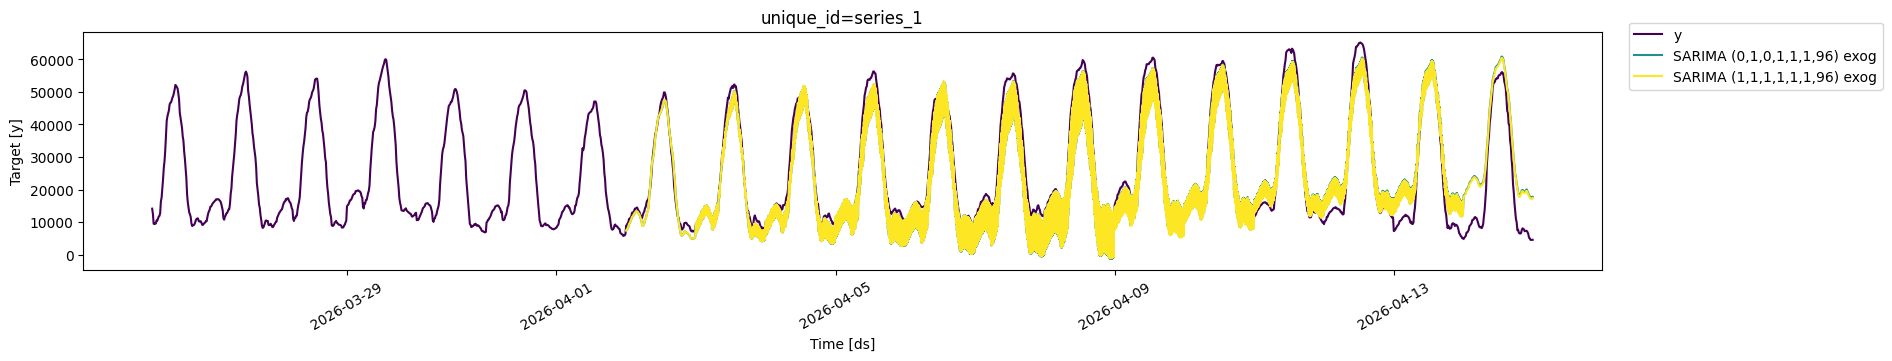

In [25]:
plot_series(
    df=data_with_exog, 
    forecasts_df=cv_df_exog.drop(["y", "cutoff"], axis=1), 
    max_insample_length=1900, 
    palette="viridis")

In [26]:
cv_eval_exog = evaluate(
    cv_df_exog.drop(["cutoff"], axis=1),
    metrics=[mae],
)
cv_eval_exog = cv_eval_exog.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
cv_eval_exog

,metric,"SARIMA (0,1,0,1,1,1,96) exog","SARIMA (1,1,1,1,1,1,96) exog"
0,mae,4967.344168,4976.248717


There is no significant improvement in MAE after using Exogenous features, so for sell_bid, its better just to use naive time series model of SARIMA

### Comparing AIC

In [ ]:
models = [
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (0,1,0,1,1,1,96)"),
    ARIMA(order=(1,1,1), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (1,1,1,1,1,1,96)"),
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(0, 1, 1), alias="SARIMA (0,1,0,0,1,3,96)"),
    #AutoTBATS(96, use_boxcox=None, bc_lower_bound=0.0, bc_upper_bound=1.0, use_trend=None, use_damped_trend=None, use_arma_errors=True, alias='AutoTBATS'),
]
models_with_exog = [
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (0,1,0,1,1,1,96) exog"),
    ARIMA(order=(1,1,1), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (1,1,1,1,1,1,96) exog")
]
sf = StatsForecast(models=models, freq="15min")
sf.fit(df=filtered_data)

In [ ]:
for i, model in enumerate(sf.fitted_[0]):
    model_name = sf.models[i]
    if 'aic' in model.model_:
        print(f"{model_name} AIC: {model.model_['aic']:.2f}")
    else:
        print(f"{model_name} does not support AIC.")

In [ ]:
sf_exog = StatsForecast(models=models_with_exog, freq="15min")
sf_exog.fit(df=data_with_exog)

In [ ]:
for i, model in enumerate(sf_exog.fitted_[0]):
    model_name = sf_exog.models[i]
    if 'aic' in model.model_:
        print(f"{model_name} AIC: {model.model_['aic']:.2f}")
    else:
        print(f"{model_name} does not support AIC (e.g., Naive/Rolling)")

### Simple Rolling Average

In [ ]:
# Rolling feature used in the CV loop below (20 days × 96 periods)
filtered_data = filtered_data.sort_values("ds").reset_index(drop=True)
filtered_data["rolling_avg_20d"] = (
    filtered_data["y"].rolling(window=96 * 20, min_periods=1).mean()
)

In [ ]:

# 1. Define the parameters for the windows
# We want to start by predicting the week starting March 13th
# The last data point the model "knows" (cutoff) would be March 12th 23:45
start_cutoff = pd.to_datetime('2026-03-12 23:45:00')
n_windows = 7  # To predict 13th-19th, 14th-20th, etc.
horizon = 96 * 7  # 7 days

cv_rolling_list = []

# 2. Loop to create each cross-validation window
for i in range(n_windows):
    # Current cutoff for this window
    current_cutoff = start_cutoff + pd.Timedelta(days=i)
    
    # Define the 7-day prediction range for this cutoff
    forecast_start = current_cutoff + pd.Timedelta(minutes=15)
    forecast_end = current_cutoff + pd.Timedelta(days=7)
    
    # Filter the rolling average data for this specific forecast range
    window_preds = filtered_data[
        (filtered_data['ds'] >= forecast_start) & 
        (filtered_data['ds'] <= forecast_end)
    ].copy()
    
    # Add the cutoff column to match cv_df structure
    window_preds['cutoff'] = current_cutoff
    
    cv_rolling_list.append(window_preds)

# 3. Combine into a single dataframe
cv_rolling_df = pd.concat(cv_rolling_list).reset_index(drop=True)

# 4. Clean up columns to match your cv_df exactly
cv_rolling_df = cv_rolling_df[['unique_id', 'ds', 'cutoff', 'y', 'rolling_avg_20d']]

# Display the first few rows and the different cutoffs created
print(f"Generated windows for cutoffs: {cv_rolling_df['cutoff'].unique()}")
cv_rolling_df.head()

In [ ]:
evaluate(
    cv_rolling_df.drop(["cutoff"], axis=1),
    metrics=[mae],
)

## Trying TBATS

In [30]:
data_normalized = filtered_data.copy()
data_normalized['y'] = data_normalized['y'] / 1000

In [31]:
models = [
    AutoTBATS(96, use_boxcox=None, bc_lower_bound=0.0, bc_upper_bound=1.0, use_trend=None, use_damped_trend=None, use_arma_errors=True, alias='AutoTBATS')
]

sf = StatsForecast(models=models, freq="15min")
cv_df_tbats = sf.cross_validation(
    h=horizon,
    df=data_normalized,
    n_windows=7,
    step_size=96,
    refit=True
)

cv_df_tbats.head()

/Users/dhruvil/Documents/EarthSync/es_env/lib/python3.12/site-packages/statsforecast/tbats.py:559: RuntimeWarning: overflow encountered in square
  log_likelihood = n * np.log(np.nansum(e**2)) - 2 * (
/Users/dhruvil/Documents/EarthSync/es_env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/dhruvil/Documents/EarthSync/es_env/lib/python3.12/site-packages/statsforecast/tbats.py:563: RuntimeWarning: overflow encountered in square
  log_likelihood = n * np.log(np.nansum(e**2))
/Users/dhruvil/Documents/EarthSync/es_env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


,unique_id,ds,cutoff,y,AutoTBATS
0,series_1,2026-04-02 00:00:00,2026-04-01 23:45:00,16.2692,13.473673
1,series_1,2026-04-02 00:15:00,2026-04-01 23:45:00,16.6904,14.219073
2,series_1,2026-04-02 00:30:00,2026-04-01 23:45:00,17.0310,14.864452
3,series_1,2026-04-02 00:45:00,2026-04-01 23:45:00,17.0762,15.238343
4,series_1,2026-04-02 01:00:00,2026-04-01 23:45:00,16.8199,15.316646


In [32]:
data_normalized['y'] = data_normalized['y'] * 1000

cv_df_tbats['y'] = cv_df_tbats['y'] * 1000
cv_df_tbats['AutoTBATS'] = cv_df_tbats['AutoTBATS'] * 1000

In [33]:
evaluate(
    cv_df_tbats.drop(["cutoff"], axis=1),
    metrics=[mae],
)

,unique_id,metric,AutoTBATS
0,series_1,mae,2386.168423


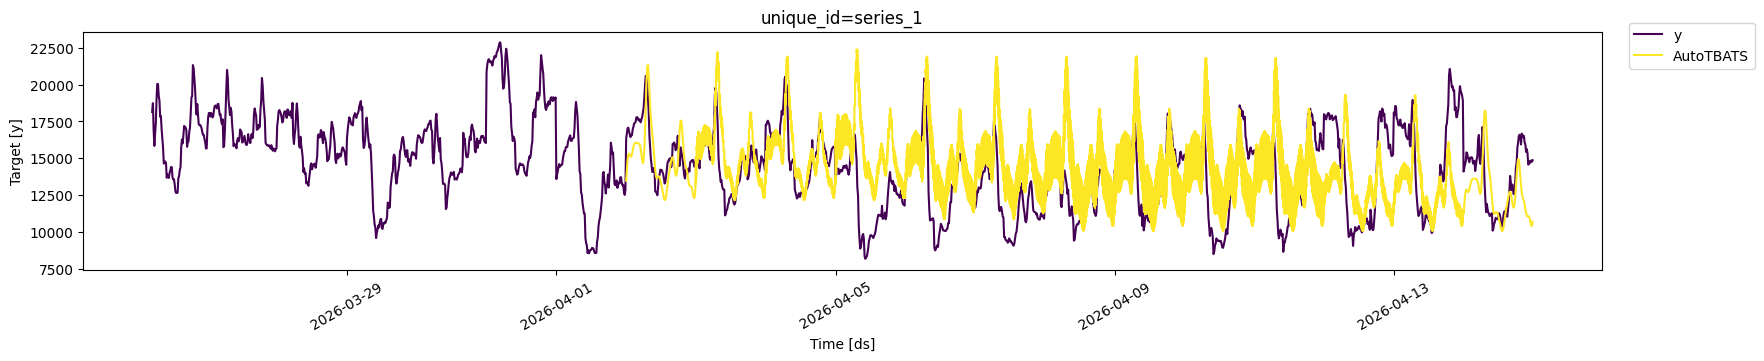

In [34]:
plot_series(
    df=data_normalized, 
    forecasts_df=cv_df_tbats.drop(["y", "cutoff"], axis=1), 
    max_insample_length=1900, 
    palette="viridis")

In [35]:
sf.fit(df=filtered_data)

/Users/dhruvil/Documents/EarthSync/es_env/lib/python3.12/site-packages/statsforecast/tbats.py:559: RuntimeWarning: overflow encountered in square
  log_likelihood = n * np.log(np.nansum(e**2)) - 2 * (
/Users/dhruvil/Documents/EarthSync/es_env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


StatsForecast(models=[AutoTBATS])

In [36]:
sf.fitted_[0][0].model_['aic']

np.float64(152571.78160504744)

## Comparing AIC

StatsForecast(models=[SARIMA (0,1,0,1,1,1,96),SARIMA (1,1,1,1,1,1,96),SARIMA (0,1,0,0,1,3,96)])

SARIMA (0,1,0,1,1,1,96) AIC: 106791.57
SARIMA (1,1,1,1,1,1,96) AIC: nan
SARIMA (0,1,0,0,1,3,96) AIC: 106764.82


StatsForecast(models=[SARIMA (0,1,0,1,1,1,96) exog,SARIMA (1,1,1,1,1,1,96) exog])

SARIMA (0,1,0,1,1,1,96) exog AIC: 106759.95
SARIMA (1,1,1,1,1,1,96) exog AIC: nan


In [ ]:
filtered_data

In [ ]:
data_with_exog

### Persist best ARIMA parameters for submission forecasts
The grid below mirrors the main SARIMA candidates used above. The lowest holdout MAE
configuration is written to `data/processed/params/ts_params.json` under the key `TARGET_COL`.

In [ ]:
from sklearn.metrics import mean_absolute_error as _mae

_df = data_indexed.reset_index().rename(columns={"period_start": "ds", TARGET_COL: "y"})[["ds", "y"]]
_df["unique_id"] = "series_1"
_test = _df.tail(HORIZON)
_train = _df.drop(_test.index).reset_index(drop=True)

_ts_candidates = [
    {"order": (0, 1, 0), "seasonal_order": (1, 1, 1), "alias": "SARIMA (0,1,0,1,1,1,96)"},
    {"order": (1, 1, 1), "seasonal_order": (1, 1, 1), "alias": "SARIMA (1,1,1,1,1,1,96)"},
    {"order": (1, 1, 1), "seasonal_order": (2, 1, 1), "alias": "SARIMA (1,1,1,2,1,1,96)"},
    {"order": (0, 1, 0), "seasonal_order": (0, 1, 3), "alias": "SARIMA (0,1,0,0,1,3,96)"},
]

_rows = []
for _c in _ts_candidates:
    _sf = StatsForecast(
        models=[
            ARIMA(
                order=_c["order"],
                season_length=96,
                seasonal_order=_c["seasonal_order"],
                alias=_c["alias"],
            )
        ],
        freq="15min",
    )
    _sf.fit(_train)
    _pred = _sf.predict(h=HORIZON)
    _yhat = _pred[_c["alias"]].values
    _rows.append(
        {
            "alias": _c["alias"],
            "mae": float(_mae(_test["y"].values, _yhat)),
            "order": list(_c["order"]),
            "seasonal_order": list(_c["seasonal_order"]),
        }
    )

_ts_results = pd.DataFrame(_rows).sort_values("mae").reset_index(drop=True)
_best = _ts_results.iloc[0].to_dict()
_existing = load_json(PARAMS_PATH) if PARAMS_PATH.exists() else {}
_existing[TARGET_COL] = {
    "target": TARGET_COL,
    "model": "statsforecast_arima",
    "horizon": HORIZON,
    "best_model": _best,
}
save_json(_existing, PARAMS_PATH)
_ts_results